In [32]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [33]:
df=pd.read_csv("/kaggle/input/cdataset/Multilablel Cyberbully Data.csv")
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam
6861,female,social,হায় রে দুদ,1,1,0,0,0
9664,female,actor,তুমি আবারও ফিরে নাচ অনুষ্ঠিত মেলায় নতুন আবেগ ন...,0,0,0,0,1
11030,female,actor,তারা আগুন দিয়ে জ্বালাই দিতে হবে,1,0,0,1,0
3545,female,politics,আসলে একটি কথা হল কি পিপীলিকার পাখা পড়ে মরিবার...,1,0,0,0,0
8295,female,social,জানু জানু জানু আই লাভ ইউর মাইজনু,1,0,0,0,0
552,male,social,বাবা আমার তো মনে হয় অতিরিক্ত মোটার জন্য তোর মে...,1,1,0,0,0
10411,female,social,সাপোর্ট করলে সাপোর্ট বেক পাবেন ইনশাআল্লাহ,0,0,1,0,1
186,female,dancer,আমি দেখে ফেলেছি,1,1,0,0,0
1171,male,social,আপনার শামি কে দেখি কেমন বুইরা নাকি,1,0,0,0,0
5646,male,actor,আল্লা যেন আপনাকে গরিবদের সাহায্য করার আরো ব...,0,0,1,0,0


In [34]:
#check the rows and columns number.
print(f"number of rows:--> {df.shape[0]} and number of columns:--> {df.shape[1]}")

number of rows:--> 12546 and number of columns:--> 8


In [35]:
#check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12546 entries, 0 to 12545
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      12546 non-null  object
 1   Profession  12546 non-null  object
 2   comment     12546 non-null  object
 3   bully       12546 non-null  int64 
 4   sexual      12546 non-null  int64 
 5   religious   12546 non-null  int64 
 6   threat      12546 non-null  int64 
 7   spam        12546 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 784.3+ KB


In [36]:
#check for missing values 
def checking_m(df):
    null_v = df.isnull().sum().sort_values(ascending=False)
    null_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    null_v = pd.concat([null_v, null_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return null_v

checking_m(df)

,Missing_Number,Missing_Percent
Gender,0,0.0
Profession,0,0.0
comment,0,0.0
bully,0,0.0
sexual,0,0.0
religious,0,0.0
threat,0,0.0
spam,0,0.0


In [37]:
#check for dublicated rows
print("Numbers of duplicated rows :",df.duplicated().sum())

Numbers of duplicated rows : 1291


In [38]:
#counting text length
df['count'] = df['comment'].str.split().str.len()

# Remove the text with words less than 3
df= df.loc[df['count']>2]


In [39]:
df.shape

(10188, 9)

In [40]:
import re

def clean_bangla_text(text):
    # Remove English letters and digits only
    text = re.sub(r'[A-Za-z0-9]', '', text)

    # Remove unwanted punctuation (but keep । ! ? , )
    text = re.sub(r'[“”"\'’‘`^~–—…•°•→←<>/\\|_=+()*&^%$#@{}[\]<>]', ' ', text)

    # Remove newlines and tabs
    text = text.replace("\n", " ").replace("\t", " ")

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['comment'] = df['comment'].apply(clean_bangla_text)

In [41]:
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam,count
11396,female,actor,জুকার বার্গকে অনুরোধ করবো প্লিজ একটা জুতার রিয়...,1,0,0,0,0,18
7686,female,social,তোরে কুত্তা দিয়া খামু,1,0,0,0,0,4
11711,female,social,ওই সংগঠনে দেশ থেকে ব্যান করে দিতে হবে,1,0,0,1,0,8
8498,female,social,পম পম কত বড়,1,1,0,0,0,4
1276,male,social,পুটকি মারুম পোলালে,1,1,0,0,0,3
5250,male,dancer,আল্লাহ সর্বশক্তিমান মানব উসিলা মোবাইল নাম্বার ...,0,0,1,0,1,19
4855,male,social,খুব সুন্দর হইছে ভাইয়া রা,0,0,0,0,0,5
2198,male,politics,বলছিলাম এই জায়গা ছারা অন্য কোথাও মাসাজ করা যায়...,0,0,0,0,0,11
9719,female,actor,আপু আপনি আমার সাথে এক হয়ে যান,0,0,0,0,0,7
11078,female,actor,এই সব অসভ্য নাস্তিকের বাচ্চাদের কারনেইবাংলাদেশ...,1,0,1,1,0,21


In [42]:
# Length of each cleaned comment (in tokens/words, split by space)
df['token_len'] = df['comment'].apply(lambda x: len(x.split()))

# Maximum token length
max_token_len = df['token_len'].max()

print("Maximum token length:", max_token_len)
df[['comment', 'token_len']].head()


Maximum token length: 178


,comment,token_len
0,এই দেশে এইসব কি হচ্ছে,5
1,মানে কি বলব,3
2,ভাই ভিডিও ফুল প্লিজ,4
3,নিজের খরচ নিজেই চালাতে পারবেন এমন ভালো একটা জব...,14
4,ভিডিও কলে রেগুলার কাজ করতে পারবেন,6


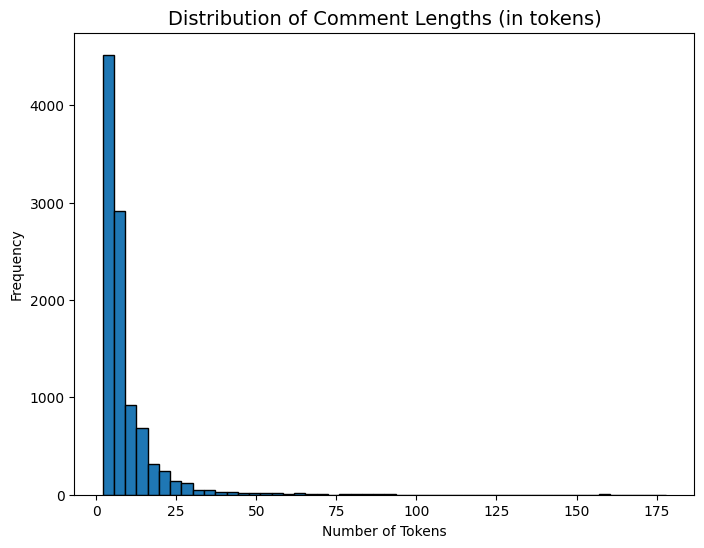

In [43]:
import matplotlib.pyplot as plt

# Distribution of token lengths (assuming you already added df['token_len'])
plt.figure(figsize=(8,6))
plt.hist(df['token_len'], bins=50, edgecolor='black')
plt.title("Distribution of Comment Lengths (in tokens)", fontsize=14)
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


In [44]:
# Define label columns
label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Prepare features and labels
texts = df['comment'].values
labels = df[label_cols].values.astype(np.float32)

labels

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 1.],
       ...,
       [1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 1., 0., 0.]], dtype=float32)

In [45]:
print(f"Dataset size: {len(texts)}")
print(f"Label distribution:\n{df[label_cols].sum()}")


Dataset size: 10188
Label distribution:
bully        6882
sexual       1802
religious    1445
threat       1403
spam          933
dtype: int64


In [46]:
# Train-validation-test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels.sum(axis=1)
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp.sum(axis=1)
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 8150, Val: 1019, Test: 1019


In [47]:
import pandas as pd
from sklearn.utils import resample
import numpy as np

# ======================================================
# BALANCE (RESAMPLE) TRAINING DATA — Match to Min Class Count
# ======================================================

label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Ensure X_train and y_train are DataFrames
X_train_df = pd.DataFrame(X_train, columns=["comment"])
y_train_df = pd.DataFrame(y_train, columns=label_cols)

# Combine for balancing
train_df = pd.concat([X_train_df.reset_index(drop=True), y_train_df.reset_index(drop=True)], axis=1)

print("\nOriginal training label distribution:")
print(train_df[label_cols].sum())

# -------------------------------------------------------
# Target = size of the smallest class
# -------------------------------------------------------
min_count = int(train_df[label_cols].sum().min())
print(f"\n🎯 Target samples per class (min-downsampled): {min_count}")

# -------------------------------------------------------
# Downsample all majority classes to match the minority
# -------------------------------------------------------
resampled_dfs = []
reduced_counts = {}

for label in label_cols:
    df_label = train_df[train_df[label] == 1]
    n_current = len(df_label)

    if n_current > min_count:
        df_downsampled = resample(
            df_label,
            replace=False,
            n_samples=min_count,
            random_state=42
        )
        resampled_dfs.append(df_downsampled)
        reduced_counts[label] = n_current - min_count
    else:
        resampled_dfs.append(df_label)
        reduced_counts[label] = 0

# Combine and shuffle
train_balanced = pd.concat(resampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# Split back into X and y
X_train = train_balanced["comment"].reset_index(drop=True).values
y_train = train_balanced[label_cols].reset_index(drop=True).values.astype(np.float32)

# -------------------------------------------------------
# Summary
# -------------------------------------------------------
print("\n✅ Final balanced training distribution:")
print(train_balanced[label_cols].sum())

print("\n📉 Reduced (removed) samples per class:")
print(reduced_counts)

print(f"\nTotal final balanced training size: {len(X_train)}")



Original training label distribution:
bully        5497.0
sexual       1447.0
religious    1160.0
threat       1116.0
spam          752.0
dtype: float32

🎯 Target samples per class (min-downsampled): 752

✅ Final balanced training distribution:
bully        2685.0
sexual       1047.0
religious    1163.0
threat       1142.0
spam          835.0
dtype: float32

📉 Reduced (removed) samples per class:
{'bully': 4745, 'sexual': 695, 'religious': 408, 'threat': 364, 'spam': 0}

Total final balanced training size: 3760


In [48]:
len(X_train), len(y_train)

(3760, 3760)